# Part 2: Modeling & Optimization - Boston Housing

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_validate, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

## 1. Load Data & Inspection

In [2]:
df = pd.read_csv('../../../data/boston_housing_cleaned.csv')
df.head()

,RM,LSTAT,PTRATIO,MEDV
0,6.575,4.98,15.3,504000.0
1,6.421,9.14,17.8,453600.0
2,7.185,4.03,17.8,728700.0
3,6.998,2.94,18.7,701400.0
4,7.147,5.33,18.7,760200.0


In [3]:
# check shape and data types
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

Shape: (489, 4)

Data Types:
RM         float64
LSTAT      float64
PTRATIO    float64
MEDV       float64
dtype: object

## 2. Train / Test Split

In [4]:
X = df[['RM', 'LSTAT', 'PTRATIO']]
y = df['MEDV']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape, "| y_train shape:", y_train.shape)
print("X_test shape: ", X_test.shape, " | y_test shape: ", y_test.shape)

X_train shape: (391, 3) | y_train shape: (391,)
X_test shape:  (98, 3)  | y_test shape:  (98,)

## 3. Model Selection & Cross-Validation Baseline

In [5]:
# Define models with Pipeline to scale features properly inside CV
models = {
    'Linear Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LinearRegression())
    ]),
    'Polynomial Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('model', LinearRegression())
    ]),
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0, random_state=42))
    ]),
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=100.0, random_state=42, max_iter=10000))
    ]),
    'Decision Tree': DecisionTreeRegressor(max_depth=4, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [6]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'r2': 'r2', 'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error'}

baseline_list = []
for name, m in models.items():
    cv = cross_validate(m, X_train, y_train, cv=kfold, scoring=scoring)
    baseline_list.append({
        'Model': name,
        'Mean R2': round(cv['test_r2'].mean(), 4),
        'Std R2': round(cv['test_r2'].std(), 4),
        'Mean RMSE': round(-cv['test_rmse'].mean(), 2),
        'Mean MAE': round(-cv['test_mae'].mean(), 2)
    })

baseline_df = pd.DataFrame(baseline_list).sort_values(by='Mean R2', ascending=False).reset_index(drop=True)
baseline_df

,Model,Mean R2,Std R2,Mean RMSE,Mean MAE
0,Gradient Boosting,0.8280,0.0186,69446.01,51802.41
1,Polynomial Regression,0.8274,0.0230,69493.03,53370.42
2,Random Forest,0.8194,0.0231,71181.31,53838.86
3,Decision Tree,0.7812,0.0144,78340.54,56551.57
4,Linear Regression,0.7133,0.0587,89486.95,66853.51
5,Ridge,0.7133,0.0586,89484.74,66851.44
6,Lasso,0.7133,0.0587,89485.89,66852.21


## 4. Hyperparameter Tuning (GridSearchCV)

In [7]:
param_grids = {
    'Polynomial Regression': {
        'poly__degree': [1, 2, 3]
    },
    'Ridge': {
        'model__alpha': [0.1, 1.0, 10.0, 100.0, 1000.0]
    },
    'Lasso': {
        'model__alpha': [10.0, 100.0, 500.0, 1000.0, 5000.0]
    },
    'Decision Tree': {
        'max_depth': [3, 4, 5, 6],
        'min_samples_split': [2, 5, 10]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [4, 6, 8]
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'max_depth': [3, 4],
        'learning_rate': [0.05, 0.1]
    }
}

tuned_models = {}

for name, m in models.items():
    if name in param_grids:
        grid = GridSearchCV(m, param_grids[name], cv=kfold, scoring='neg_root_mean_squared_error')
        grid.fit(X_train, y_train)
        tuned_models[name] = grid.best_estimator_
        print(f"{name:22s} -> Best Params: {grid.best_params_}")
    else:
        tuned_models[name] = m

Polynomial Regression  -> Best Params: {'poly__degree': 3}
Ridge                  -> Best Params: {'model__alpha': 1.0}
Lasso                  -> Best Params: {'model__alpha': 500.0}
Decision Tree          -> Best Params: {'max_depth': 4, 'min_samples_split': 10}
Random Forest          -> Best Params: {'max_depth': 4, 'n_estimators': 50}
Gradient Boosting      -> Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

## 5. Model Comparison After Tuning

In [8]:
comp_list = []

for name, m in tuned_models.items():
    cv = cross_validate(m, X_train, y_train, cv=kfold, scoring=scoring)
    comp_list.append({
        'Model': name,
        'Mean R2': round(cv['test_r2'].mean(), 4),
        'Std R2': round(cv['test_r2'].std(), 4),
        'Mean RMSE': round(-cv['test_rmse'].mean(), 2),
        'Mean MAE': round(-cv['test_mae'].mean(), 2)
    })

comparison_df = pd.DataFrame(comp_list).sort_values(by='Mean R2', ascending=False).reset_index(drop=True)
comparison_df

,Model,Mean R2,Std R2,Mean RMSE,Mean MAE
0,Gradient Boosting,0.8319,0.0204,68592.60,50653.28
1,Polynomial Regression,0.8294,0.0230,69065.41,52701.31
2,Random Forest,0.8286,0.0219,69359.03,51513.70
3,Decision Tree,0.7855,0.0130,77534.40,56400.83
4,Linear Regression,0.7133,0.0587,89486.95,66853.51
5,Ridge,0.7133,0.0586,89484.74,66851.44
6,Lasso,0.7133,0.0585,89483.43,66848.24


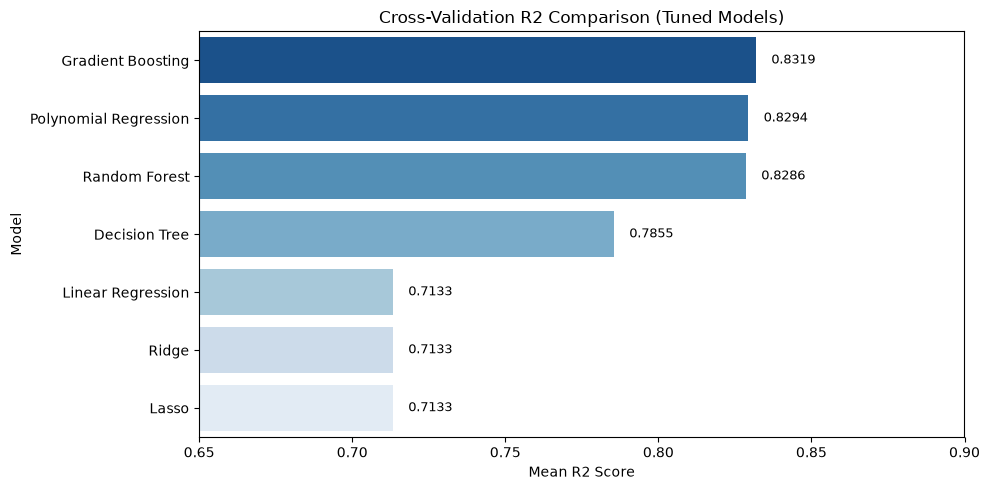

In [9]:
plt.figure(figsize=(10, 5))
sns.barplot(data=comparison_df, x='Mean R2', y='Model', palette='Blues_r')
plt.title('Cross-Validation R2 Comparison (Tuned Models)')
plt.xlabel('Mean R2 Score')
plt.xlim(0.65, 0.9)
plt.show()

## 6. Final Model Selection & Evaluation on Test Set

In [10]:
# We choose Polynomial Regression (Degree 3) as the final model
final_model = tuned_models['Polynomial Regression']

# Fit on full training set
final_model.fit(X_train, y_train)

# Evaluate once on test set
y_pred = final_model.predict(X_test)

test_r2 = r2_score(y_test, y_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_mae = mean_absolute_error(y_test, y_pred)

print("Final Model (Polynomial Regression Deg 3) Test Results:")
print("-----------------------------------------------------")
print(f"Test R2:   {test_r2:.4f}")
print(f"Test RMSE: ${test_rmse:,.2f}")
print(f"Test MAE:  ${test_mae:,.2f}")

Final Model (Polynomial Regression Deg 3) Test Results:
-----------------------------------------------------
Test R2:   0.8223
Test RMSE: $62,498.28
Test MAE:  $48,324.78

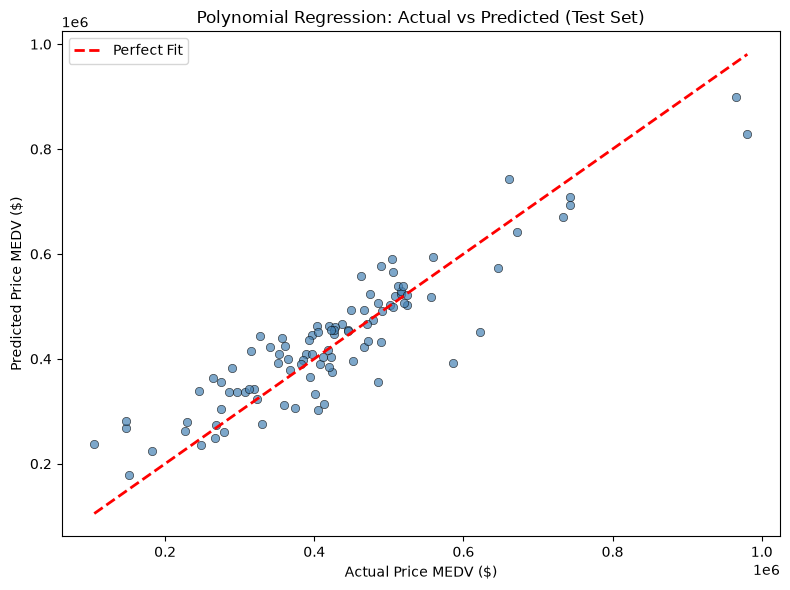

In [11]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.7, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')
plt.xlabel('Actual Price MEDV ($)')
plt.ylabel('Predicted Price MEDV ($)')
plt.title('Polynomial Regression: Actual vs Predicted (Test Set)')
plt.legend()
plt.show()

## 7. Feature Importance

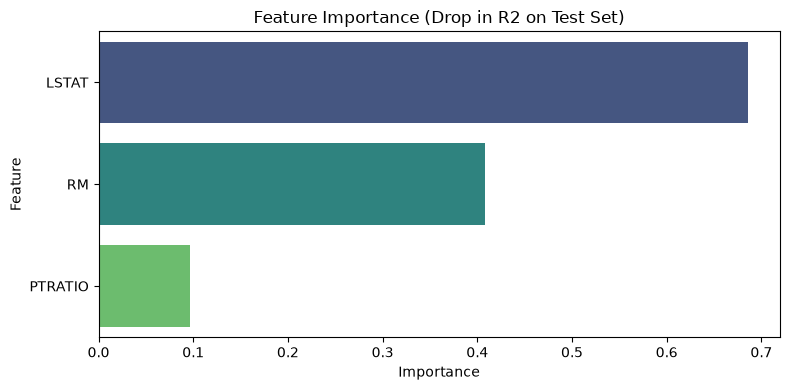

,Feature,Importance
0,LSTAT,0.6854
1,RM,0.4082
2,PTRATIO,0.0963


In [12]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=10, random_state=42)

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': perm.importances_mean.round(4)
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

plt.figure(figsize=(8, 4))
sns.barplot(data=importance_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Drop in R2 on Test Set)')
plt.xlabel('Importance')
plt.show()

importance_df